# Exposure to Russian Stocks (03/03/2025)

Request from US

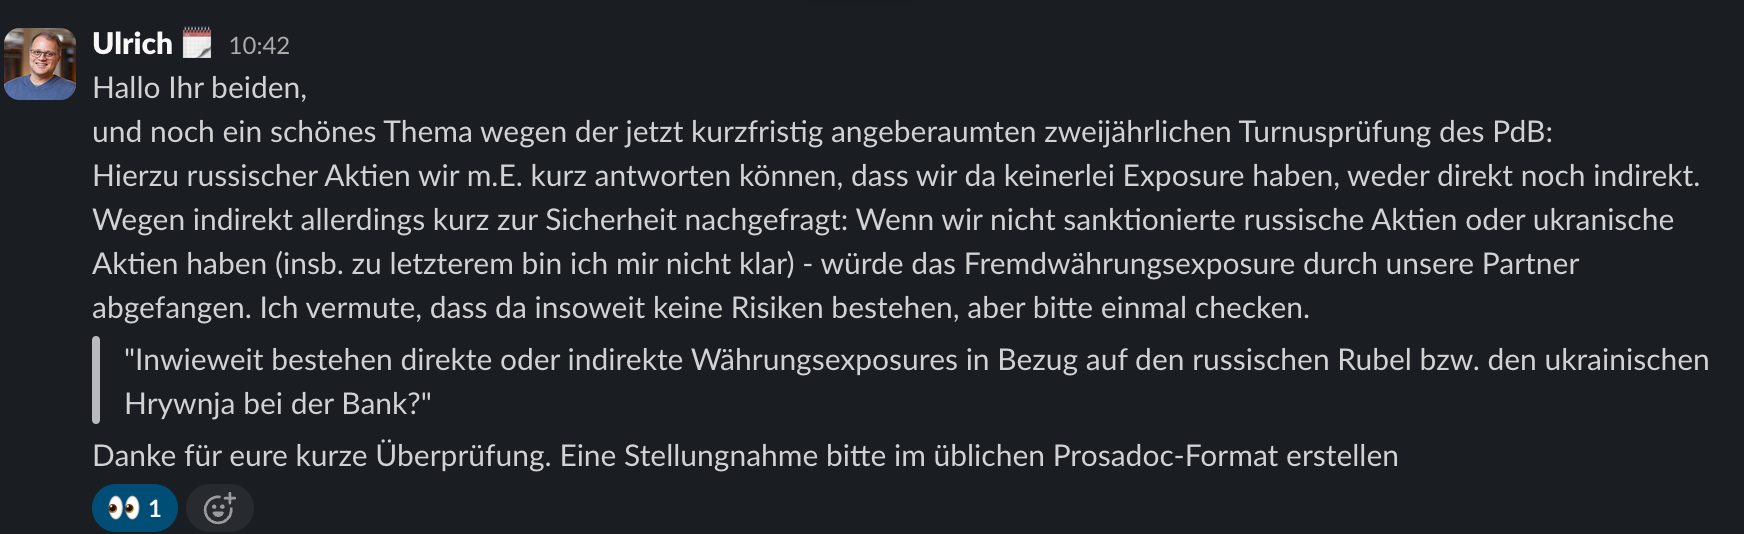

### Importing Libraries

In [217]:
import sys
sys.path.append('/Users/fabioballoni/Development/repos/risk/')
from risk_pylibrary import *
from risk_pylibrary.projects.pnl import pnl_support as pnl_sup
import openpyxl

In [226]:
reload(pnl_sup)

<module 'risk_pylibrary.projects.pnl.pnl_support' from '/Users/fabioballoni/Development/repos/risk/risk_pylibrary/projects/pnl/pnl_support.py'>

### Running Queries

##### Setting Report Date

In [218]:
report_date=date(2024,12,31)

#### Russian Stocks Info

In [210]:
qry='''
-- GENERIC INSTRUMET INFO
with SECS_INFO_0 as (
SELECT 
    SECS.INSTRUMENT_ID,
    SECS.INSTRUMENT_TYPE,
    SECS.NAME_SHORT,
    SECS.NAME_OFFICIAL,
    SECS.NOTIONAL_CURRENCY AS CURRENCY_MART,
    SECS.INDEX_NAME AS STOCK_INDEX_NAME
FROM 
    TEAMS_PRD.CORE_MART.MRT_CURR__INSTRUMENTS AS SECS
),
-- WM DATA
SECS_INFO_1 as (
SELECT
    WM."isin" AS INSTRUMENT_ID,
    WM.gd172::text AS CURRENCY,
    WM.gd161::text AS COUNTRY,
    WM.gd162::text AS ISSUER_COUNTRY
FROM
    teams_prd.source_instrument_partners.src__instrument_partners__wmdaten_instruments_view AS WM
WHERE
    WM."isin" in (SELECT SECS_INFO_0.INSTRUMENT_ID FROM SECS_INFO_0)
)
SELECT
    SECS_INFO_0.INSTRUMENT_ID,
    SECS_INFO_0.NAME_SHORT,
    SECS_INFO_0.NAME_OFFICIAL,
    SECS_INFO_0.INSTRUMENT_TYPE,
    SECS_INFO_1.CURRENCY,
    SECS_INFO_0.CURRENCY_MART,
    SECS_INFO_1.COUNTRY,
    SECS_INFO_1.ISSUER_COUNTRY,
    SECS_INFO_0.STOCK_INDEX_NAME
FROM
    SECS_INFO_0 AS SECS_INFO_0
    LEFT JOIN
        SECS_INFO_1
    ON
        SECS_INFO_1.INSTRUMENT_ID = SECS_INFO_0.INSTRUMENT_ID
WHERE
    SECS_INFO_1.CURRENCY='RUB' OR SECS_INFO_1.COUNTRY='RU' OR SECS_INFO_1.CURRENCY='UAH' OR SECS_INFO_1.COUNTRY='UA'
'''

df_info=db.run_query(query=qry)
# Mark as ADR/GDR
df_info['is_right']=[1 if str(k).endswith('(ADR)') or str(k).endswith('(GDR)') else 0 for k in df_info.name_short]
df_info['report_date']=report_date

#### Get TR Trading Book Positions

In [219]:
qry_tr_book='''
SELECT
    EXP.REPORT_DATE,
    EXP.SEC_ACC_NO,
    PRICES.INSTRUMENT_TYPE,
    EXP.INSTRUMENT_ID,
    PRICES.CLOSE_MID_PRICE_CLEAN,
    EXP.QUANTITY,
    (PRICES.CLOSE_MID_PRICE_CLEAN*EXP.QUANTITY) AS MKT_EUR
FROM
    TEAMS_PRD.RISK_FUNCTION_TRANSFORM.TRF__RISK_FUNCTION_MRM_BOOK_TOTAL_EXPOSURES EXP
LEFT JOIN
    (SELECT 
        PRX.REPORT_DATE,  -- Added this
        PRX.INSTRUMENT_ID,
        PRX.INSTRUMENT_TYPE,
        PRX.CLOSE_MID_PRICE_CLEAN  -- Added this
    FROM 
        TEAMS_PRD.RISK_FUNCTION_PUBLISH.PBL__RISK_FUNCTION_MRM_BOOK_MSL_PRICES PRX 
    WHERE 
        PRX.REPORT_DATE=%s) AS PRICES
    ON
        PRICES.REPORT_DATE=EXP.REPORT_DATE AND PRICES.INSTRUMENT_ID=EXP.INSTRUMENT_ID
WHERE
    EXP.REPORT_DATE=%s
AND
    EXP.INSTRUMENT_ID IN (%s);
'''

df_book=db.run_query(query=qry_tr_book%(db.sqldate(report_date),db.sqldate(report_date),db.joinpad(df_info.instrument_id)))
df_book=df_book.set_index(['report_date','instrument_id'])
# Filtering df_info for relevant instrument_ids
tmp_info=df_info.set_index('instrument_id').reindex(df_book.index.get_level_values(1))[['name_short','currency','currency_mart']]
# Building output
out_tr_book=df_book.join(tmp_info,on='instrument_id').dropna(subset=['mkt_eur'])

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZLLUuMwEEV%2FxaVZ25KTQIIqCRUIgVDAhDxmwU6xO4nKsuRRy7Hh60fOY4pZwGJ2Kul2n6u%2B3b%2BucxXswaI0ekDiiJEAdGJSqbcDslpOwh4J0AmdCmU0DMg7ILke9lHkquCj0u30HH6XgC7wjTTy5mFASqu5ESiRa5EDcpfwxej5ibcixgUiWOdx5FSSovSsnXMFp7SqqqhqR8ZuaYsxRtkV9apG8oN8QhTfMwprnEmMOpfU%2Fk9fIGLKOg3CKzxhdiq8kfo4gu8o66MI%2BcNyOQtnPxdLEozOv7s1Gssc7ALsXiawmj8dDaB3cP982Wt3uxGUYQLaWaHCOEJtqo0SGSQmL0rnG0f%2BRDeQUmW20o9rOh6QIpMpzB%2FN61t%2B2bma3IwfVvtM3e8mq9EFbkVSZSITr5OXbH23kfVdQoJf53BbTbhTxBKmuonU%2BSvWughZO2TdJevxFuNxL2Ld%2BI0EYx%2Bp1MIdKs%2B%2BvdMULBTlWskkMpkTB4uiKOhf9xTqLO59mHXdzhAfJ%2Fu6E3cpoqFNbuS4Ovxgww7%2FYyB9%2BrnBaRFffDbT8cx4W%2B%2FBxNhcuK%2Bji6P4cCPTcHOQcsiFVKM0tYDoI1TKVLcWhPP77mwJhA6P1H83fv

In [220]:
out_tr_book

sec_acc_no instrument_type  close_mid_price_clean  \
report_date instrument_id                                                      
2024-12-31  US5591892048   9800001301           STOCK               3.850000   
            US3682872078   9800001301           STOCK               2.535000   
            US0373763087   9800001301           STOCK               0.800000   
            US50218G2066   9800001301           STOCK               1.530000   
            US67011E2046   9800001301           STOCK               0.108500   
            US7785291078   9800001301           STOCK               4.200000   
            US8766292051   9800001301           STOCK              21.250000   
            US80585Y3080   9800001301           STOCK               3.880000   
            US55315J1025   9800001301           STOCK               0.084000   
            US69343R1014   9800001301           STOCK               2.350000   
            US6074091090   9800001301           STOCK               3.960000   

                           quantity   mkt_eur                 name_short  \
report_date instrument_id                                                  
2024-12-31  US5591892048   1.102800  4.245780  Magnitogorsk Iron & Steel   
            US3682872078   0.258700  0.655805              Gazprom (ADR)   
            US0373763087   7.238800  5.791040            Mosenergo (ADR)   
            US50218G2066   4.109400  6.287382                  LSR Group   
            US67011E2046   0.145100  0.015743         Novolipetsky Metal   
            US7785291078   2.792700 11.729340           Rostelecom (ADR)   
            US8766292051   0.553000 11.751250              Tatneft (ADR)   
            US80585Y3080   0.422100  1.637748             Sberbank (ADR)   
            US55315J1025   0.771900  0.064840       Norilsk Nickel (ADR)   
            US69343R1014   3.545600  8.332160             Aeroflot (GDR)   
            US6074091090   0.660300  2.614788   Mobile Telesystems (ADR)   

                          currency currency_mart  
report_date instrument_id                         
2024-12-31  US5591892048       RUB          None  
            US3682872078       RUB          None  
            US0373763087       RUB          None  
            US50218G2066       RUB          None  
            US67011E2046       RUB          None  
            US7785291078       RUB          None  
            US8766292051       RUB          None  
            US80585Y3080       RUB          None  
            US55315J1025       RUB          None  
            US69343R1014       RUB          None  
            US6074091090       RUB          None

##### Check Trades on Prop Exposures

In [227]:
df_trades=pnl_sup.get_trades_pnl(account='caracalla',startdate=date(2022,1,1),enddate=report_date, syms=list(out_tr_book.index.get_level_values(1)))

In [228]:
df_trades

,time,booking_date,symbol,side,booking_category,booking_type,price,quantity,multiplier
0,2023-01-30 16:03:24.765,2022-12-30,US0373763087,B,TRADING,BUY,0.010000,7.238800,1
1,2023-01-30 16:04:12.917,2022-12-30,US3682872078,B,TRADING,BUY,0.010000,0.258700,1
2,2023-01-30 16:04:57.231,2022-12-30,US50218G2066,B,TRADING,BUY,0.010000,4.109400,1
3,2023-01-30 16:05:36.134,2022-12-30,US5591892048,B,TRADING,BUY,0.010000,1.102800,1
4,2023-01-30 16:07:22.203,2022-12-30,US6074091090,B,TRADING,BUY,0.010000,0.660300,1
5,2023-01-30 16:08:15.249,2022-12-30,US67011E2046,B,TRADING,BUY,22.600000,0.145100,1
6,2023-01-30 16:09:08.560,2022-12-30,US69343R1014,B,TRADING,BUY,0.010000,3.545600,1
7,2023-01-30 16:09:44.078,2022-12-30,US7785291078,B,TRADING,BUY,0.010000,2.792700,1
8,2023-01-30 16:10:25.854,2022-12-30,US8766292051,B,TRADING,BUY,0.010000,0.553000,1
9,2023-01-30 16:45:17.211,2022-12-30,US55315J1025,B,TRADING,BUY,0.010000,0.771900,1


#### Get Security Services Exposure

In [213]:
qry_fx='''
SELECT 
    *
FROM 
    TEAMS_PRD.RISK_FUNCTION_PUBLISH.PBL__RISK_FUNCTION_FX__FX_EXPOSURE_CURRENCY_SPLIT
WHERE 
    REPORT_DATE=%s
AND
    CURRENCY IN ('RUB','UAH')
AND
    ACCOUNT_TYPE='Securities Services Accounts'
ORDER BY 1 DESC;
'''

out_fx=db.run_query(query=qry_fx%(db.sqldate(report_date)))

#### Get Customer Trading Book Positions

In [215]:
qry_cust_trading='''
SELECT
    CALENDAR_DATE AS REPORT_DATE,
    INSTRUMENT_ID,
    SUM(VOLUME) AS MKT_EUR
FROM
    TEAMS_PRD.CORE_MART.MRT_CURR__AUC
WHERE
    instrument_id in (%s)
AND
    calendar_date=%s
GROUP BY 1,2
'''

df_cust_pos=db.run_query(query=qry_cust_trading%(db.joinpad(df_info.instrument_id),db.sqldate(report_date)))
out_cust_pos=df_cust_pos.set_index(['report_date','instrument_id'])
out_cust_pos=out_cust_pos.join(df_info.set_index('instrument_id'), on='instrument_id')


### Build Output and Perform Analytics

In [167]:
out_total=pd.DataFrame(columns=['tr_trading_book','tr_sec_services_fx','customer_book'],index=[report_date])
if out_tr_book.empty is False: 
    out_total['tr_trading_book']= out_tr_book.mkt_eur.sum()
if out_fx.empty is False: 
    out_total['tr_sec_services_fx']= out_fx.mkt_eur.sum()
if out_tr_book.empty is False: 
    out_total['customer_book']= out_tr_book.mkt_eur.sum()